[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana17_CalculosEstocastico_y_Valuacion.ipynb)

In [ ]:
import numpy as np
import math
import pandas as pd
from scipy.stats import norm
import yfinance as yf

import matplotlib.pyplot as plt

# Movimiento Browniano

Es un proceso estocástico con las siguientes propiedades:
- Inicia en cero
- $W_t$ tiene incrementos independientes
- $W_t - W_s$ se comporta como unas normal con media 0 y varianza $t-s$

In [ ]:
np.random.seed(1000)

In [ ]:
def simulate_1d_bm(nsteps=1000, t=0.01):
    steps = [ np.random.randn()*np.sqrt(t) for i in range(nsteps) ]
    y = np.cumsum(steps)
    x = [ t*i for i in range(nsteps) ]
    return x, y

In [ ]:
nsims = 5
simulation_data = {}
for i in range(nsims):
    x, y = simulate_1d_bm()
    simulation_data['y{col}'.format(col=i)] = y
    simulation_data['x'] = x

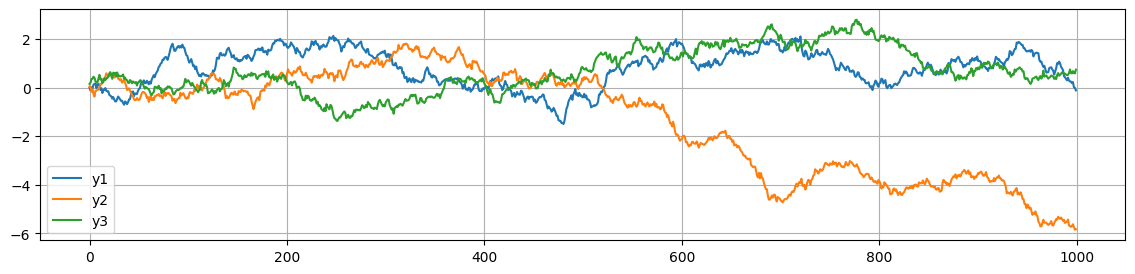

In [ ]:
plt.figure(figsize=(14,3))
plt.plot(simulation_data['y1'], label='y1')
plt.plot(simulation_data['y2'], label='y2')
plt.plot(simulation_data['y3'], label='y3')
plt.legend()
plt.grid()

# Movimiento browniano con "drift"

Es una transformación en la que si $B(t)$ es un movimiento browniano, se le agrega un termino llamado "drift" (en español se le conoce como "deriva"):

$$X(t) = B(t) + \mu t$$

In [ ]:
def simulate_1d_bm_with_drift(nsteps=1000, t=0.01, mu=0.5):
    steps = [ mu*t + np.random.randn()*np.sqrt(t) for i in range(nsteps) ]
    y = np.cumsum(steps)
    x = [ t*i for i in range(nsteps) ]
    return x, y

In [ ]:
nsims = 5
simulation_data = {}
for i in range(nsims):
    x, y = simulate_1d_bm_with_drift(mu=-2)
    simulation_data['y{col}'.format(col=i)] = y
    simulation_data['x'] = x

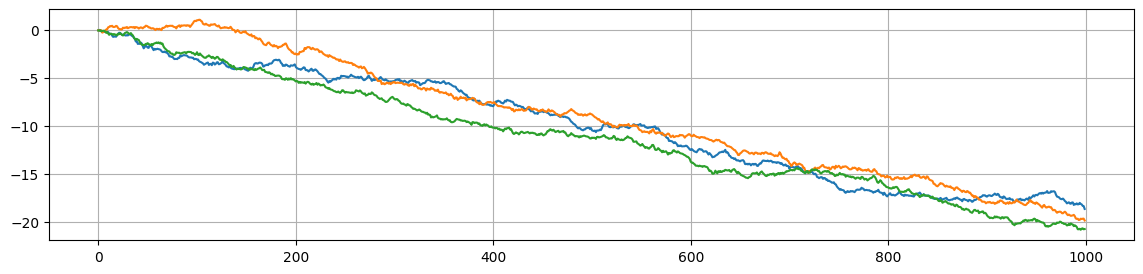

In [ ]:
plt.figure(figsize=(14,3))
plt.plot(simulation_data['y1'])
plt.plot(simulation_data['y2'])
plt.plot(simulation_data['y3'])
plt.grid()

# Movimiento Browniano Geométrico

Este tipo de modelo es muy utilizado para la predicción de precios de activos (se verá algunas semanas mas adelante)

Se ve del siguiente modo:

$$ G(t) = G(0) exp\left[(\mu - \frac{1}{2}\sigma^{2}) + \sigma X(t) \right] $$

$ G(t)$ no es movimiento browniano, pero $log(G(t))$ si lo es, pues:

$$ log [ G(t) ] = log[G(0)] + (\mu - \frac{1}{2}\sigma^{2}) + \sigma X(t) $$

Propiedad: Cuando el logaritmo del precio de un activo sigue un movimiento browniano entonces los rendimientos logarítmicos son distribuidos normalmente.

"si yo estudio, entonces paso el examen"
Lo unico que yo puedo derivar de esta verdad es lo siguiente:
"Yo no paso el examen, entonces no estudie"


a -> b

-b -> -a

In [ ]:
def simulate_1d_gbm(nsteps=1000, t=1, mu=0.0001, sigma=0.02):
    steps = [ (mu - (sigma**2)/2) + np.random.randn()*sigma for i in range(nsteps) ]
    y = np.exp(np.cumsum(steps))
    x = [ t*i for i in range(nsteps) ]
    return x, y

In [ ]:
nsims = 5
simulation_data = {}
for i in range(nsims):
    x, y = simulate_1d_gbm()
    simulation_data['y{col}'.format(col=i)] = y
    simulation_data['x'] = x

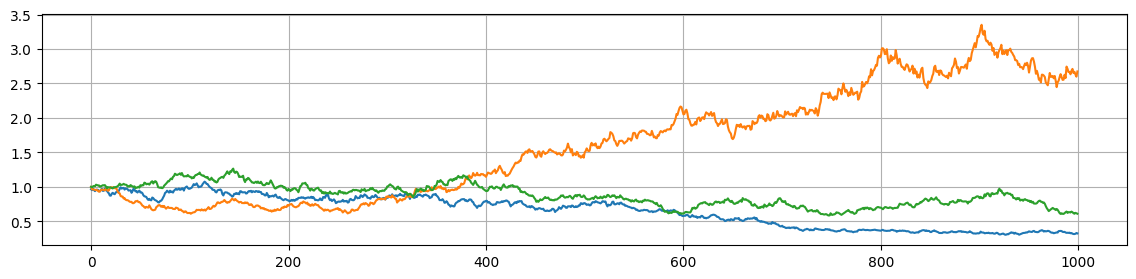

In [ ]:
plt.figure(figsize=(14,3))
plt.plot(simulation_data['y1'])
plt.plot(simulation_data['y2'])
plt.plot(simulation_data['y3'])
plt.grid()

# Simulación Monte Carlo para valuación de Opciones

En esta clase veremos como utilizar el método de muestre MonteCarlo para dar un precio a nuestras opciones de tipo Call Europeo.

In [ ]:
data = yf.download(
        # Lista de tickers o puede ser un string
        tickers = "GOOGL ^IRX",

        # Parámetro "period", tambien se puede utilizar start/end
        # periodos válidos: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (opcional, default es '1mo')
        period = "1y",

        # Peidr datos por intervalo (incluye intradía si es menor a 60 days)
        # intervalos válidos: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (opcional, default es '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (opcional, default es 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close']
data

[*********************100%***********************]  2 of 2 completed


Ticker,GOOGL,^IRX
Date,,
2023-11-29 00:00:00+00:00,NaN,5.240
2023-11-30 00:00:00+00:00,132.202637,5.238
2023-12-01 00:00:00+00:00,131.534302,5.215
2023-12-04 00:00:00+00:00,128.950699,5.223
2023-12-05 00:00:00+00:00,130.666458,5.243
...,...,...
2024-11-22 00:00:00+00:00,164.759995,4.415
2024-11-25 00:00:00+00:00,167.649994,4.405
2024-11-26 00:00:00+00:00,169.119995,4.395


Crea un simulador de Movimiento Browniano Geométrico.

$$
S_T = S_0 \exp \left[ \left( r - \dfrac{\sigma^2}{2} \right) T + \sigma\epsilon\sqrt{T}  \right],
$$
donde $\epsilon$ es una simulación de una Normal estándar.

Ésta ecuación es la que nos dará la simulación del precio del del activo en el futuro al llevar a cabo simulaciones de variables aleatorias normales. Esto nos ayudará e encontrar el precio de la opción.

Como extra, solucionar esta ecuación es bastante complejo, pero se puede hacer con una herramienta llamada ecuación de Black-Scholes.

In [ ]:
data

Ticker,GOOGL,^IRX
Date,,
2023-11-29 00:00:00+00:00,NaN,5.240
2023-11-30 00:00:00+00:00,132.202637,5.238
2023-12-01 00:00:00+00:00,131.534302,5.215
2023-12-04 00:00:00+00:00,128.950699,5.223
2023-12-05 00:00:00+00:00,130.666458,5.243
...,...,...
2024-11-22 00:00:00+00:00,164.759995,4.415
2024-11-25 00:00:00+00:00,167.649994,4.405
2024-11-26 00:00:00+00:00,169.119995,4.395


In [ ]:
data.dropna(inplace=True)

In [ ]:
# Renombrando columna
data.rename(columns={'^IRX':'IRX'}, inplace=True)

# Tasa de interes vista como porcentaje
data['IRX'] = data['IRX']/100

# Retornos logaritmicos
data['Vol. GOOGL'] = np.nan
data['log_ret'] = np.log(data['GOOGL']) - np.log(data['GOOGL'].shift(1))

# Calculando volatilidad y anualizarla
fechas_vol = data.index
for cada_fecha in fechas_vol[125:]:
    data_for_vol = fechas_vol[(cada_fecha - fechas_vol < pd.Timedelta(days=180)) & (cada_fecha - fechas_vol >= pd.Timedelta(days=0))] # 120 dias para 6 meses
    data.loc[cada_fecha, 'Vol. GOOGL'] = np.std(data['log_ret'][data_for_vol].values, ddof=1)*np.sqrt(252)


In [ ]:
data

Ticker,GOOGL,IRX,Vol. GOOGL,log_ret
Date,,,,
2023-11-30 00:00:00+00:00,132.202637,0.05238,NaN,NaN
2023-12-01 00:00:00+00:00,131.534302,0.05215,NaN,-0.005068
2023-12-04 00:00:00+00:00,128.950699,0.05223,NaN,-0.019838
2023-12-05 00:00:00+00:00,130.666458,0.05243,NaN,0.013218
2023-12-06 00:00:00+00:00,129.698853,0.05243,NaN,-0.007433
...,...,...,...,...
2024-11-22 00:00:00+00:00,164.759995,0.04415,0.250116,-0.017269
2024-11-25 00:00:00+00:00,167.649994,0.04405,0.252091,0.017389
2024-11-26 00:00:00+00:00,169.119995,0.04395,0.250540,0.008730


In [ ]:
un_dato = data.iloc[-3,:].copy()
un_dato

,2024-11-26 00:00:00+00:00
Ticker,
GOOGL,169.119995
IRX,0.043950
Vol. GOOGL,0.250540
log_ret,0.008730


Recordemos la fórmula:
$$
S_T = S_0 \exp \left[ \left( r - \dfrac{\sigma^2}{2} \right) T + \sigma\epsilon\sqrt{T}  \right],
$$


Tambien en lugar de $ (r -  \dfrac{\sigma^2}{2})$ podemos utilizar el retorno esperado del activo.

In [ ]:
valores = np.array([])

K = 179 # Nosotros escogemos el precio de STRIKE

for i in range(10000):
  normal = np.random.standard_normal(1)

  St = un_dato.GOOGL*np.exp((un_dato.IRX - 0.5*un_dato['Vol. GOOGL']**2)*30/360 + un_dato['Vol. GOOGL']*normal*np.sqrt(30/360))

  valores = np.append(valores, max(St - K,0))

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
valores[10:]

array([0.        , 3.65048725, 0.        , ..., 0.        , 0.        ,
       0.        ])

In [ ]:
valores.mean()

1.6303515932781452

(array([8026.,  179.,  138.,  157.,  156.,  136.,  131.,  115.,  112.,
          97.,   92.,   83.,   73.,   79.,   49.,   41.,   43.,   40.,
          33.,   27.,   20.,   21.,   23.,   25.,   18.,   13.,    7.,
          11.,    6.,    4.,    7.,    3.,    5.,    4.,    3.,    4.,
           4.,    2.,    3.,    1.,    1.,    3.,    0.,    1.,    1.,
           0.,    0.,    1.,    1.,    1.]),
 array([ 0.        ,  0.84819953,  1.69639906,  2.54459859,  3.39279811,
         4.24099764,  5.08919717,  5.9373967 ,  6.78559623,  7.63379576,
         8.48199529,  9.33019481, 10.17839434, 11.02659387, 11.8747934 ,
        12.72299293, 13.57119246, 14.41939199, 15.26759152, 16.11579104,
        16.96399057, 17.8121901 , 18.66038963, 19.50858916, 20.35678869,
        21.20498822, 22.05318774, 22.90138727, 23.7495868 , 24.59778633,
        25.44598586, 26.29418539, 27.14238492, 27.99058444, 28.83878397,
        29.6869835 , 30.53518303, 31.38338256, 32.23158209, 33.07978162,
        33.92798

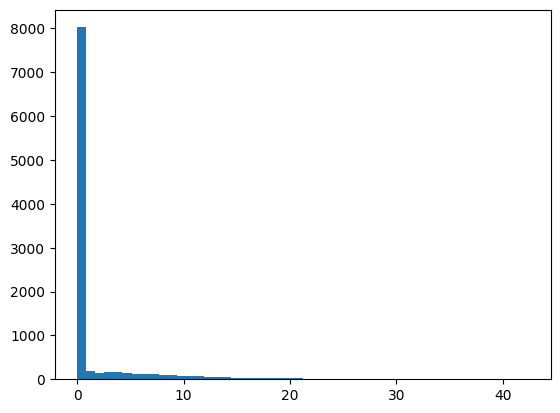

In [ ]:
plt.hist(valores, bins=50)

# Black-Scholes

In [ ]:
data = yf.download(
        # Lista de tickers o puede ser un string
        tickers = "GOOGL ^IRX",

        # Parámetro "period", tambien se puede utilizar start/end
        # periodos válidos: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (opcional, default es '1mo')
        period = "1y",

        # Peidr datos por intervalo (incluye intradía si es menor a 60 days)
        # intervalos válidos: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (opcional, default es '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (opcional, default es 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close']
data

[*********************100%***********************]  2 of 2 completed


Ticker,GOOGL,^IRX
Date,,
2023-11-29 00:00:00+00:00,NaN,5.240
2023-11-30 00:00:00+00:00,132.202637,5.238
2023-12-01 00:00:00+00:00,131.534302,5.215
2023-12-04 00:00:00+00:00,128.950699,5.223
2023-12-05 00:00:00+00:00,130.666458,5.243
...,...,...
2024-11-22 00:00:00+00:00,164.759995,4.415
2024-11-25 00:00:00+00:00,167.649994,4.405
2024-11-26 00:00:00+00:00,169.119995,4.395


In [ ]:
data.rename(columns={'^IRX': 'IRX'}, inplace=True)

In [ ]:
# Convertir un porcentaje a número
data['IRX'] = data['IRX']/100

In [ ]:
# Calculo de log-retornos
data['Vol. GOOGL'] = np.nan
data['log_ret'] = np.log(data['GOOGL']) - np.log(data['GOOGL'].shift(1))

<Axes: >

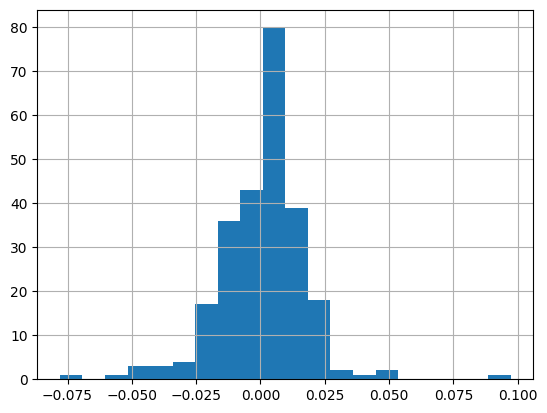

In [ ]:
data.log_ret.hist(bins=20)

In [ ]:
# Calculando la volatilidad de las acciones de GOOGLE
fechas_vol = data.index
for cada_fecha in fechas_vol[125:]:
    data_for_vol = fechas_vol[(cada_fecha - fechas_vol < pd.Timedelta(days=180)) & (cada_fecha - fechas_vol >= pd.Timedelta(days=0))] # 120 dias para 6 meses
    data.loc[cada_fecha, 'Vol. GOOGL'] = np.std(data['log_ret'][data_for_vol].values, ddof=1)*np.sqrt(252)


Al resolver la ecuación diferencial se llega la siguiente formula, que permite valuar el Call (suponiendo que no paga dividendos):

\begin{align}
  C(S_t, t) &= N(d_1)S_t - N(d_2)Ke^{-r(T - t)} \\
     d_1 &= \frac{1}{\sigma\sqrt{T - t}}\left[\ln\left(\frac{S_t}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)(T - t)\right] \\
     d_2 &= d_1 - \sigma\sqrt{T - t}. \\
\end{align}

Donde:

\begin{align}
t &: \mbox{tiempo} \\
S_t &: \mbox{Precio del activo al tiempo }t \\
K &: \mbox{Precio acordado en el contrato} \\
r &: \mbox{Tasa libre de riesgo}\\
\sigma^2 &: \mbox{Volatilidad del activo subyacente} \\
N(\cdot) &: \mbox{Función de distribución de la normal (probabilidad acumulada)}
\end{align}

In [ ]:
def ByS_call(spot, strike, risk_free, vol, tiempo):
    d_1 = (np.log(spot/strike) + (risk_free + 0.5*vol*vol)*(tiempo/360)) / (vol * np.sqrt(tiempo/360))
    d_2 = d_1 - vol*np.sqrt(tiempo/360)
    value = spot * norm.cdf(d_1) - strike * np.exp(-risk_free * (tiempo/360)) * norm.cdf(d_2)
    return value

In [ ]:
data

Ticker,GOOGL,IRX,Vol. GOOGL,log_ret
Date,,,,
2023-11-29 00:00:00+00:00,NaN,0.05240,NaN,NaN
2023-11-30 00:00:00+00:00,132.202637,0.05238,NaN,NaN
2023-12-01 00:00:00+00:00,131.534302,0.05215,NaN,-0.005068
2023-12-04 00:00:00+00:00,128.950699,0.05223,NaN,-0.019838
2023-12-05 00:00:00+00:00,130.666458,0.05243,NaN,0.013218
...,...,...,...,...
2024-11-22 00:00:00+00:00,164.759995,0.04415,0.250116,-0.017269
2024-11-25 00:00:00+00:00,167.649994,0.04405,0.252091,0.017389
2024-11-26 00:00:00+00:00,169.119995,0.04395,0.250540,0.008730


In [ ]:
un_dato = data.iloc[-1,:].copy()
un_dato

,2024-11-29 00:00:00+00:00
Ticker,
GOOGL,168.949997
IRX,0.043730
Vol. GOOGL,0.249525
log_ret,-0.001656


In [ ]:
tiempo_madurez = 30

In [ ]:
un_dato.GOOGL

168.9499969482422

In [ ]:
ByS_call(un_dato.GOOGL, 179, un_dato.IRX, un_dato['Vol. GOOGL'], tiempo_madurez)

1.6349317923376319

# Ejercicio

Vimos como crear trayectorias de un proceso estocástico. Si quisieramos valuar una opcion americana que tiene tiempo de expiración $T=10$, ¿que podriamos hacer?

Proponga una solución y explique porque podría funcionar y porque no.

In [ ]:
# Espacio para el ejercicio


